<a href="https://colab.research.google.com/github/julmiha25-sys/MathStatistica/blob/main/%D0%90-%D0%92_%D1%82%D0%B5%D1%81%D1%82_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_Marketpele_Feed/A_B_%D1%82%D0%B5%D1%81%D1%82_Marketpele_Feed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Названия групп: ['A' 'B']

Количество дубликатов по составному ключу: 0

Объем выборки 126

На сколько % отличается количество наблюдений в экспериментальных группах: 0.0 %

Соотношение RPM для групп А/B - статистика: 0.3603953776301174
p_value > 0.05 - гипотезу о равенстве распределений RPM в группах A и B не отвергаем на уровне значимости а=0.05

Соотношение RPS для групп А/B - статистика: 0.5193323434581332
p_value > 0.05 - гипотезу о равенстве распределений RPM в группах A и B не отвергаем на уровне значимости а=0.05

Соотношение Paid CTR для групп А/B - статистика: 0.2297727656720219
p_value > 0.05 - гипотезу о равенстве распределений Paid CTR в группах A и B не отвергаем на уровне значимости а=0.05

Соотношение Organic CTR для групп А/B - статистика: 3.5673397845089507e-11
p_value <= 0.05 - гипотезу о равенстве распределений Organic CTR в группах A и B отвергаем на уровне значимости а=0.05

Среднее значение Organic CTR группы A больше B на: 52.42 %


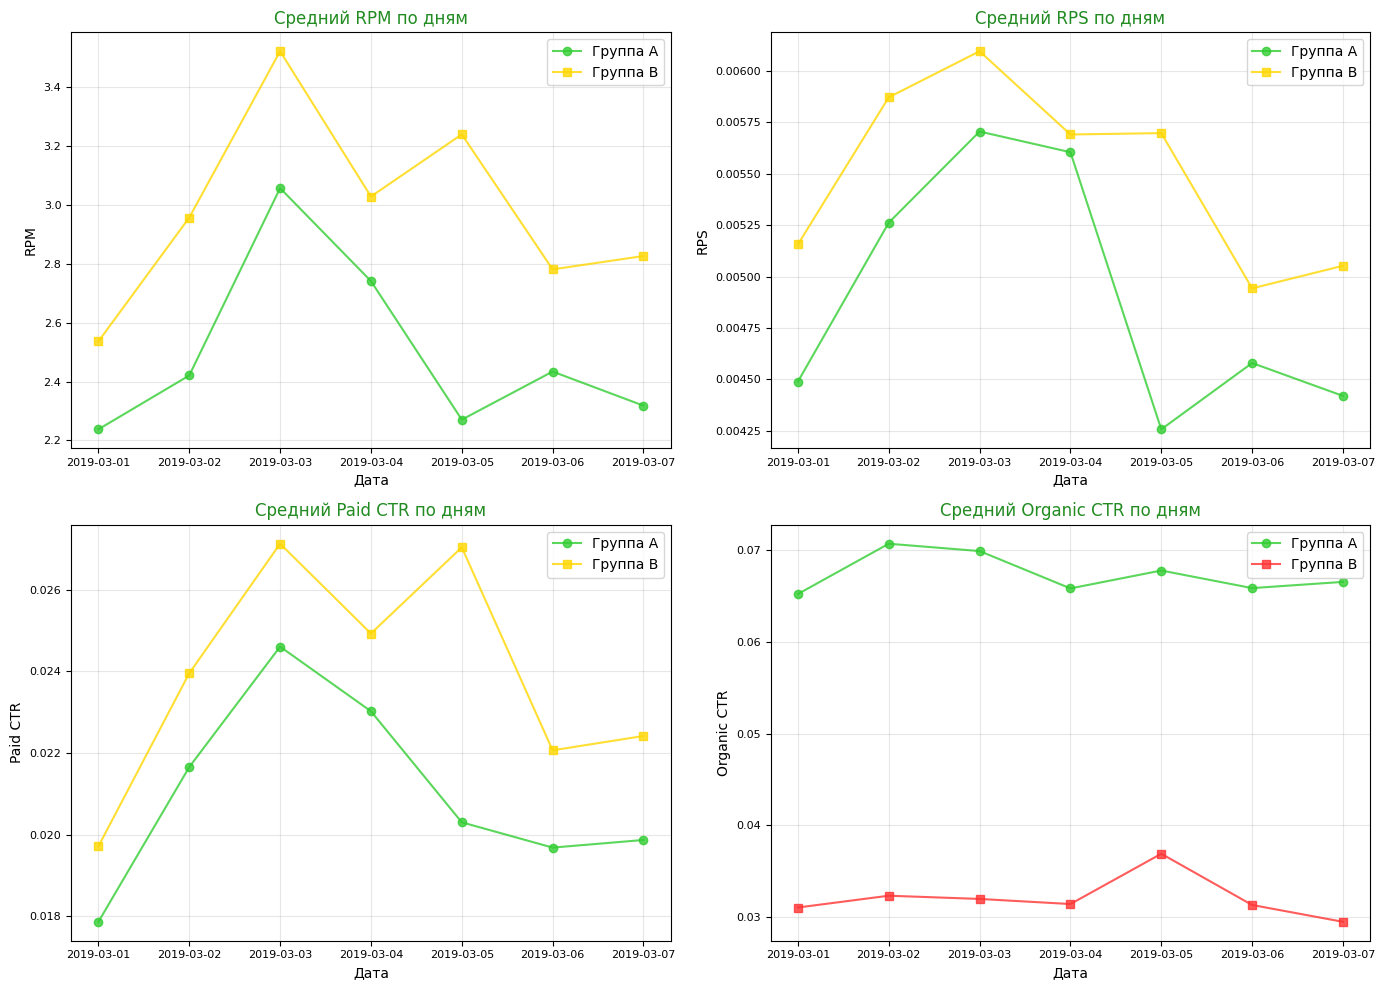

In [85]:
import pandas as pd
import numpy as np
from scipy import stats
df = pd.read_excel("marketpele_ab_test.xlsx")
# Определение названий для экспериментальной и контрольной групп
print("Названия групп:", df['group_name'].unique())
# Проверка корректности сплитования
# Проверка дубликатов (уникальный ключ: date, platform, publisher и group name)
key = df.groupby(['date', 'publisher_id', 'platform', 'group_name']).size()
dup = key[key > 1]
print("\nКоличество дубликатов по составному ключу:", len(dup))
# Дубликатов нет - сплитование корректное
# Объем выборки
print("\nОбъем выборки", len(df))

# На сколько процентов отличается количество наблюдений в экспериментальных группах? (округлите до сотых процента)
A = df[df['group_name'] == 'A'].copy()
B = df[df['group_name'] == 'B'].copy()
print("\nНа сколько % отличается количество наблюдений в экспериментальных группах:", round((len(B)-len(A))/len(A)*100,2),"%")
# Отличие < 1% - сплитование допустимо

# Отличаются ли стат значимо группы в А/В-тесте?
# Проверка по метрике RPM
A['RPM'] = A['revenue'] / A['pageviews'] * 1000
B['RPM'] = B['revenue'] / B['pageviews'] * 1000
stat = stats.ttest_ind(A['RPM'], B['RPM'])
print(f"\nСоотношение RPM для групп А/B - статистика: {stat.pvalue}")
if stat.pvalue <= 0.05:
   print("p_value <= 0.05 - гипотезу о равенстве распределений RPM в группах A и B отвергаем на уровне значимости а=0.05")
else:
   print("p_value > 0.05 - гипотезу о равенстве распределений RPM в группах A и B не отвергаем на уровне значимости а=0.05")
# p_value > 0.05 - гипотезу о равенстве распределений RPM в группах A и B не отвергаем на уровне значимости а=0.05

# Проверка по метрике RPS
A['RPS'] = A['revenue'] / A['sessions']
B['RPS'] = B['revenue'] / B['sessions']
stat = stats.ttest_ind(A['RPS'], B['RPS'])
print(f"\nСоотношение RPS для групп А/B - статистика: {stat.pvalue}")
if stat.pvalue <= 0.05:
   print("p_value <= 0.05 - гипотезу о равенстве распределений RPM в группах A и B отвергаем на уровне значимости а=0.05")
else:
   print("p_value > 0.05 - гипотезу о равенстве распределений RPM в группах A и B не отвергаем на уровне значимости а=0.05")
# p_value > 0.05 - гипотезу о равенстве распределений RPS в группах A и B не отвергаем на уровне значимости а=0.05

# Проверка по метрике Paid CTR
A['Paid CTR'] = A['sponsord_clicks'] / A['pageviews']
B['Paid CTR'] = B['sponsord_clicks'] / B['pageviews']
stat = stats.ttest_ind(A['Paid CTR'], B['Paid CTR'])
print(f"\nСоотношение Paid CTR для групп А/B - статистика: {stat.pvalue}")
if stat.pvalue <= 0.05:
   print("p_value <= 0.05 - гипотезу о равенстве распределений Paid CTR в группах A и B отвергаем на уровне значимости а=0.05")
else:
   print("p_value > 0.05 - гипотезу о равенстве распределений Paid CTR в группах A и B не отвергаем на уровне значимости а=0.05")
# p_value > 0.05 - гипотезу о равенстве распределений RPS в группах A и B не отвергаем на уровне значимости а=0.05

# Проверка по метрике Organic CTR
A['Organic CTR'] = A['organic_clicks'] / A['pageviews']
B['Organic CTR'] = B['organic_clicks'] / B['pageviews']
stat = stats.ttest_ind(A['Organic CTR'], B['Organic CTR'])
print(f"\nСоотношение Organic CTR для групп А/B - статистика: {stat.pvalue}")
if stat.pvalue <= 0.05:
   print("p_value <= 0.05 - гипотезу о равенстве распределений Organic CTR в группах A и B отвергаем на уровне значимости а=0.05")
else:
   print("p_value > 0.05 - гипотезу о равенстве распределений Organic CTR в группах A и B не отвергаем на уровне значимости а=0.05")
# p_value < 0.05 - гипотезу о равенстве распределений Organic CTR в группах A и B отвергаем на уровне значимости а=0.05
# Посмотрим направление различий
if A['Organic CTR'].mean() > B['Organic CTR'].mean():
  print("\nСреднее значение Organic CTR группы A больше B на:", round((A['Organic CTR'].mean()-B['Organic CTR'].mean())/A['Organic CTR'].mean()*100,2), "%")
elif  A['Organic CTR'].mean() < B['Organic CTR'].mean():
  print("\nСреднее значение Organic CTR группы A меньше B на:", round((B['Organic CTR'].mean()-A['Organic CTR'].mean())/A['Organic CTR'].mean()*100,2), "%")
else:
  print("\nСреднее значение Organic CTR в группах А и B равны:", A['Organic CTR'].mean(), B['Organic CTR'].mean())
# Вывод:группа A показала лучшие результаты

# Визуализация
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = ['RPM', 'RPS', 'Paid CTR', 'Organic CTR']
titles = ['Средний RPM по дням', 'Средний RPS по дням', 'Средний Paid CTR по дням', 'Средний Organic CTR по дням']
for i, (metric, title) in enumerate(zip(metrics, titles)):
    row, col = i // 2, i % 2
    A_daily = A.groupby('date')[metric].mean().reset_index()
    B_daily = B.groupby('date')[metric].mean().reset_index()
    axes[row, col].plot(A_daily['date'], A_daily[metric], alpha=0.8, color='#32CD32', marker='o', label='Группа A')
    if metric=='Organic CTR':
      axes[row, col].plot(B_daily['date'], B_daily[metric], alpha=0.8, color='#FF3333', marker='s', label='Группа B')
    else:
      axes[row, col].plot(B_daily['date'], B_daily[metric], alpha=0.8, color='#FFD700', marker='s', label='Группа B')
    axes[row, col].set_title(title, color='#228B22')
    axes[row, col].set_xlabel('Дата')
    axes[row, col].set_ylabel(metric)
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)
    axes[row, col].tick_params(axis='x', labelsize=8, rotation=0)
    axes[row, col].tick_params(axis='y', labelsize=8, rotation=0)
plt.tight_layout()
plt.show()